# FLIRT Feature Extraction Visualization
This notebook visualizes the physiological and biomechanical features extracted by the `flirt` library. 
The purpose of this visualization is to demonstrate the quality of the data going into the Machine Learning pipeline, fulfilling the methodology requirements for the thesis.

## Feature Selection
The `flirt` library extracts hundreds of statistical features across multiple domains (time domain, frequency domain, and non-linear entropy). To prevent overcrowding, we have selected a representative subset:
- **Mean & Standard Deviation:** Basic intensity indicators.
- **Skewness:** Indicates directional bias in the acceleration (e.g., gravity or repetitive asymmetric movements).
- **Entropy:** Measures the complexity/unpredictability of the signal (e.g., rhythmic walking has low entropy, erratic movements have high entropy).
- **Heart Rate Stats:** Direct physiological markers of metabolic expenditure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Aesthetic settings for thesis
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.3)

# Load the independent reference device dataset
# This dataset is free of the data loss bugs and data leakage flaws.
DATA_PATH = Path("Acc_pipe/data/processed/flirt_reference.csv")
df = pd.read_csv(DATA_PATH, index_col=0)

# Drop any rows where METs (our Ground Truth) is missing
df = df.dropna(subset=['mets'])

print(f"Loaded {len(df)} epochs with valid Ground Truth METs.")

Loaded 88 epochs with valid Ground Truth METs.


## 1. Feature Distributions
We inspect the shape of the data distributions. This helps confirm whether our features are normally distributed or skewed, which explains why the Random Forest (which handles non-linear distributions well) outperformed the Linear Regression model.

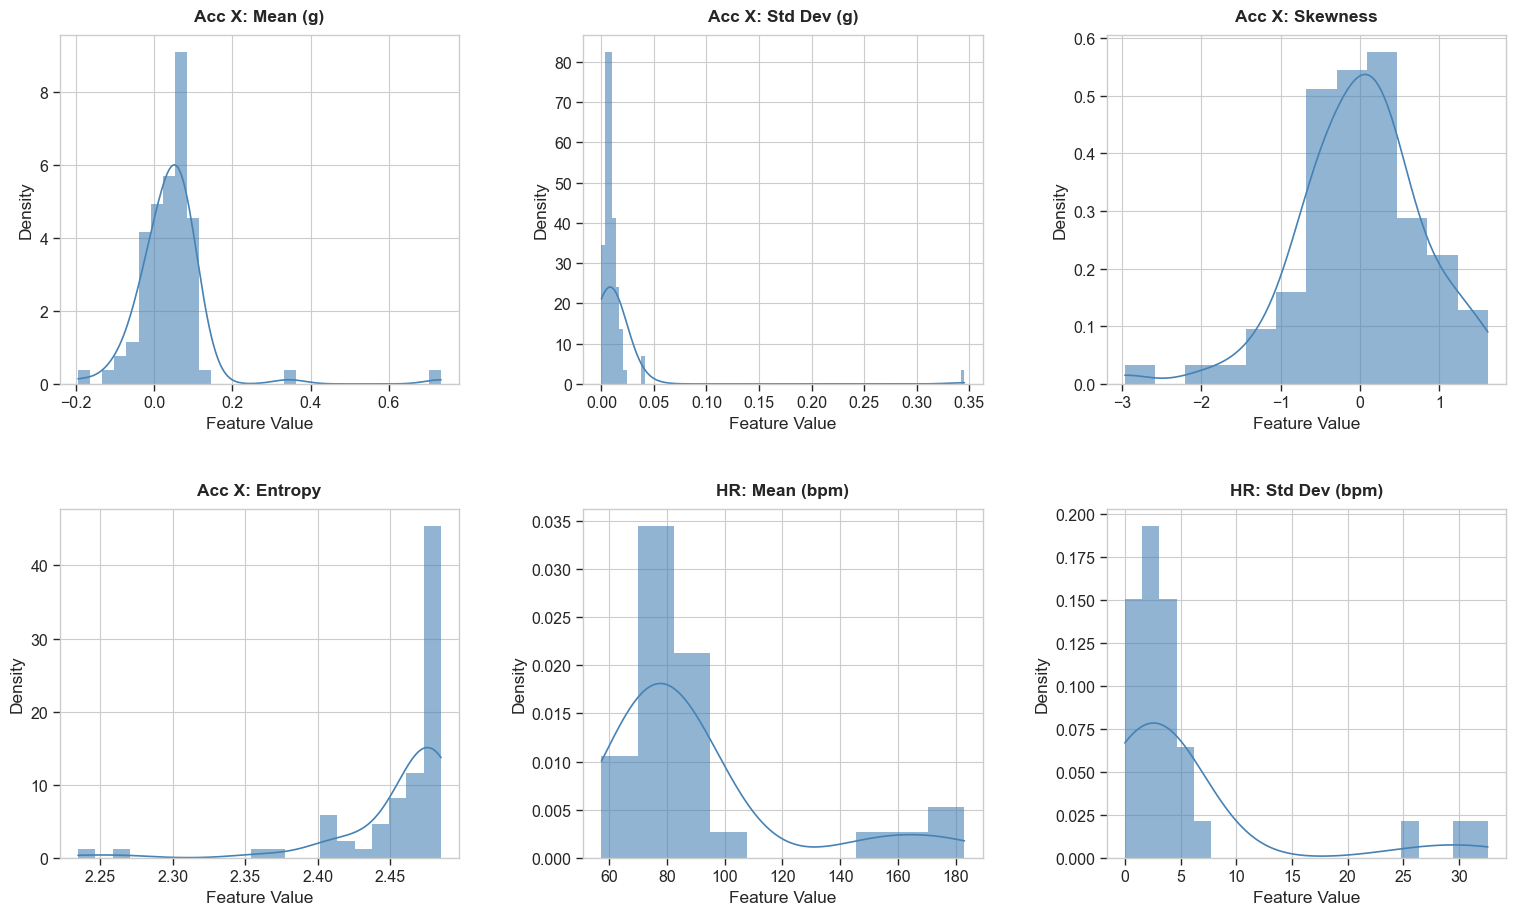

In [2]:
features_to_plot = [
    ('reference_acc_x_mean', 'Acc X: Mean (g)'),
    ('reference_acc_x_std', 'Acc X: Std Dev (g)'),
    ('reference_acc_x_skewness', 'Acc X: Skewness'),
    ('reference_acc_x_entropy', 'Acc X: Entropy'),
    ('hr_polar_stat_hr_polar_mean', 'HR: Mean (bpm)'),
    ('hr_polar_stat_hr_polar_std', 'HR: Std Dev (bpm)')
]

actual_features = [f for f in features_to_plot if f[0] in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (col_name, display_name) in enumerate(actual_features):
    ax = axes[idx]
    data_to_plot = df[col_name].dropna()
    sns.histplot(data=data_to_plot, kde=True, ax=ax, color='steelblue', stat='density', alpha=0.6, linewidth=0)
    ax.set_title(display_name, fontweight='bold', pad=10)
    ax.set_xlabel('Feature Value')
    ax.set_ylabel('Density')

plt.tight_layout(pad=3.0)
plt.show()

## 2. Feature Correlation Heatmap
A critical part of feature extraction is understanding how features relate to the target variable (`mets`) and to each other.
- **High Correlation to METs:** Good predictor (e.g., Heart Rate Mean).
- **High Correlation between features (Multicollinearity):** This explains why we needed `Ridge Regression` (which penalizes multicollinearity) instead of standard OLS regression.

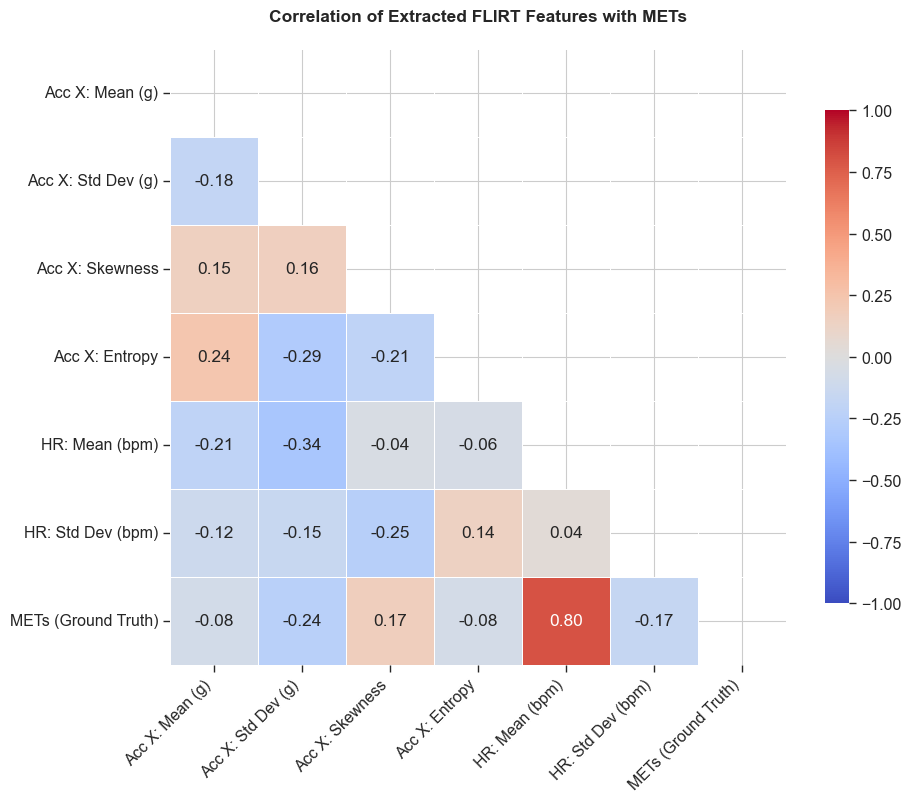

In [3]:
corr_cols = [f[0] for f in actual_features] + ['mets']
corr_display_names = [f[1] for f in actual_features] + ['METs (Ground Truth)']

corr_data = df[corr_cols].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1,
    square=True,
    xticklabels=corr_display_names,
    yticklabels=corr_display_names,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title("Correlation of Extracted FLIRT Features with METs", fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

## 3. Best Feature vs. Energy Expenditure (METs)
We isolate the feature that has the strongest absolute mathematical relationship with the ground truth and plot it.

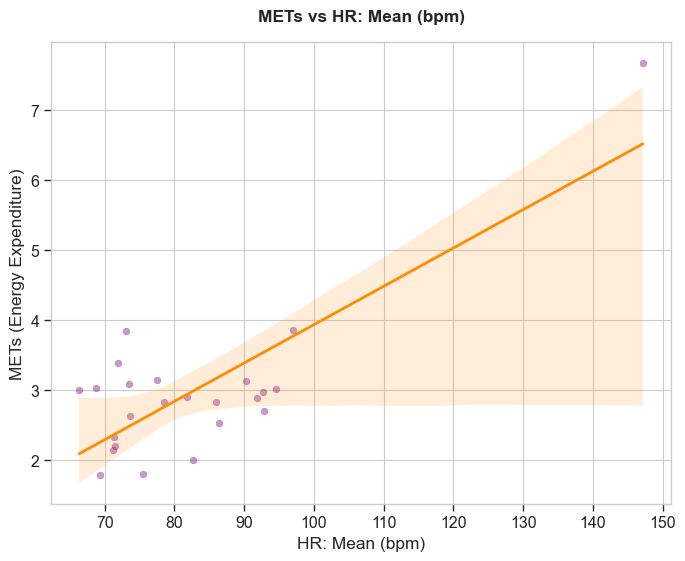

In [4]:
corrs = corr_matrix['mets'].drop('mets').abs()
best_feature_col = corrs.idxmax()
best_feature_name = next(f[1] for f in actual_features if f[0] == best_feature_col)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=corr_data[best_feature_col], 
    y=corr_data['mets'], 
    alpha=0.4, 
    edgecolor=None,
    color='purple'
)
sns.regplot(
    x=corr_data[best_feature_col], 
    y=corr_data['mets'], 
    scatter=False, 
    color='darkorange',
    line_kws={'linewidth': 2}
)
plt.title(f"METs vs {best_feature_name}", fontweight='bold', pad=15)
plt.xlabel(best_feature_name)
plt.ylabel("METs (Energy Expenditure)")
plt.show()